In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import json
import glob
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import numpy as np
import seaborn as sns
from statsmodels.stats.multitest import multipletests
from scipy.stats import pearsonr
import sys
plt.rcParams['svg.fonttype'] = 'none'

In [3]:
with open("fit_palette.json") as f:
    pal = json.load(f)

In [ ]:
sys.path.append("../../bosperrus-package/")
from bosperrus import *

sys.path.append("../src/")
from figure_2 import main

In [5]:
np.random.seed(41)

In [6]:
conconc = main().drop(["Unnamed: 0.1", "Unnamed: 0"], axis=1)

calculating fits and their quality...
calculating fits and their quality...
calculating fits and their quality...
calculating fits and their quality...
calculating fits and their quality...
calculating fits and their quality...
calculating fits and their quality...
calculating fits and their quality...


In [12]:
conconc = conconc[conconc["measure"].isin(["betweenness", "degree", "closeness", "clustering", "pagerank"])].copy()

In [14]:
def get_sign(x, eps=0.0001):
    if np.abs(x) < eps:
        return "none"
    if x > 0:
        return "increase"
    else:
        return "decrease"
        
conconc["sign_border_effect"] = conconc["observed_effect_strength"].apply(lambda x: get_sign(x))

In [15]:
markers = {"decrease": "v", "increase": "^", "none": "o"}  # if fit monotonocially decreases, then error is positive at borders

In [16]:
index = {"delaunay": 0,
#         "knn_k=5": 1,
         "knn_k=10": 1,
#         "knn_k=15": 3,
#        "rnn_r=0.02": 4,
         "rnn_r=0.03": 2,
#         "rnn_r=0.04": 6,
#         "rnn_r=0.05": 7
         }

In [17]:
plot_subset = conconc[np.isin(conconc["graph_type"], list(index.keys()))]

KeyError: 'graph_type'

In [ ]:
for (gt, m), df in plot_subset.groupby(["graph_type", "measure"]):
    combis = [("observed_half_life", "observed_effect_strength"),
             ("observed_half_life", "num_edges"),
             ("observed_half_life", "num_nodes"),
             ("observed_effect_strength", "num_edges"),
             ("observed_effect_strength", "num_nodes")]
    for c in combis:
        stat = pearsonr(df[c[0]], df[c[1]]).statistic
        if stat > 0.3:
            print(gt, m, c[0], c[1], stat)

In [ ]:
# In the new bosperrus API, fit_quality stores the *best* fit's relative likelihood
# under the column "scaled_relative_likelihood_over_baseline" (one value per measure).
# The old per-fit columns ('Piecewise Linear Fit_scaled_relative_likelihood_over_Constant Fit', etc.)
# no longer exist; use "scaled_relative_likelihood_over_baseline" directly.

In [ ]:
best_fit_rel_ll = plot_subset["scaled_relative_likelihood_over_baseline"]

In [ ]:
plot_subset["rel_ll_best"] = best_fit_rel_ll

In [ ]:
def clip_percentiles(group):
    x_low, x_high = group["observed_half_life"].quantile([0.01, 0.99])
    y_low, y_high = group["observed_effect_strength"].quantile([0.01, 0.99])

    return group[
        group["observed_half_life"].between(x_low, x_high) &
        group["observed_effect_strength"].between(y_low, y_high)
    ]

filtered = (
    plot_subset
    .reset_index()
    .groupby(["graph_type", "measure"], group_keys=False)
    .apply(clip_percentiles)
)

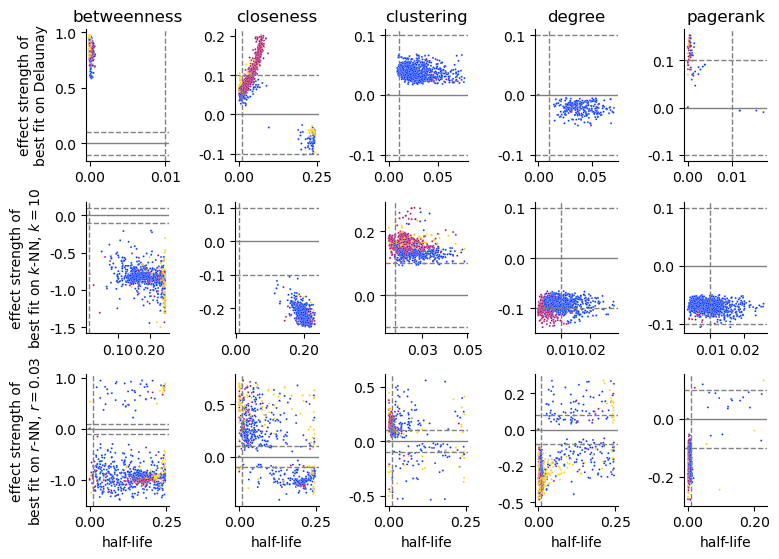

In [19]:
g = sns.relplot(data=filtered.reset_index(), x='observed_half_life', y='observed_effect_strength', hue="best_fit_type", row="graph_type", col="measure", palette=pal, hue_order=pal.keys(), kind='scatter', facet_kws={"sharex": False, "sharey": False}, alpha=1, height=1.9, aspect=5/6, row_order=index.keys(), col_order=sorted(conconc["measure"].unique()), s=2, legend=False)
for i, ax in enumerate(g.axes.flat):
    ax.axhline(0, linestyle='-', linewidth=1, color="grey")
    ax.axhline(-0.1, linestyle='--', linewidth=1, color="grey")
    ax.axhline(0.1, linestyle='--', linewidth=1, color="grey")

    ax.axvline(0.01, linestyle='--', linewidth=1, color="grey")
    #ax.axvline(0.1, linestyle='--', linewidth=1, color="grey")
    #ax.axvline(1, linestyle='-', linewidth=1, color="grey")

    #ax.set_xlim(0, 1)
    
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
    #ax.set_xscale("log")   
    #ax.set_yscale("symlog")   

    original_title = ax.get_title()

    if i >= 5:
        ax.title.set_visible(False)
    else:
        ax.set_title(original_title.split("=")[-1][1:])

    if i % 5 == 0:
        if i == 0:
            ax.set_ylabel(f"effect strength of\nbest fit on Delaunay")
        if i == 5:
            ax.set_ylabel(f"effect strength of\nbest fit on $k$-NN, $k=10$")
        if i == 10:
            ax.set_ylabel(f"effect strength of\nbest fit on $r$-NN, $r=0.03$")

    if i >= 10 :
        ax.set_xlabel(f"half-life")

plt.tight_layout()
plt.savefig("../result_plots/fits/observed_effect_strength_over_observed_half_life.svg", bbox_inches="tight")

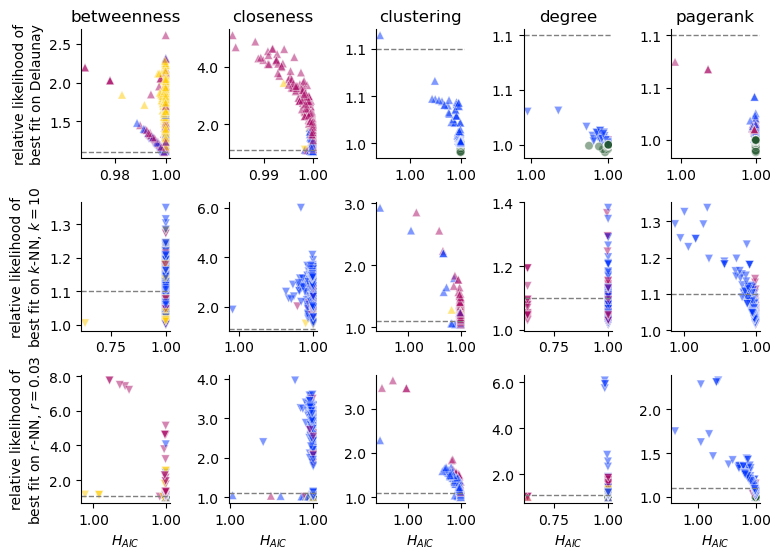

In [20]:
g = sns.relplot(data=filtered, x="entropy_AIC_weights", y="rel_ll_best", hue="best_fit_type", style="sign_border_effect", row="graph_type", col="measure", palette=pal, hue_order=pal.keys(), markers=markers, legend=False, kind='scatter', facet_kws={"sharex": False, "sharey": False}, alpha=0.5, height=1.9, aspect=5/6, col_order=sorted(conconc["measure"].unique()), row_order=index.keys())
for i, ax in enumerate(g.axes.flat):
    ax.axhline(1.1, linestyle='--', linewidth=1, color="grey")
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
    
    original_title = ax.get_title()

    if i >= 5:
        ax.title.set_visible(False)
    else:
        ax.set_title(original_title.split("=")[-1][1:])
    if i % 5 == 0:
        if i == 0:
            ax.set_ylabel(f"relative likelihood of\nbest fit on Delaunay")
        if i == 5:
            ax.set_ylabel(f"relative likelihood of\nbest fit on $k$-NN, $k=10$")
        if i == 10:
            ax.set_ylabel(f"relative likelihood of\nbest fit on $r$-NN, $r=0.03$")
    if i >= 10 :
        ax.set_xlabel("$H_{AIC}$")
plt.tight_layout()
plt.savefig("../result_plots/fits/relative_likelihoods_over_model_agreement.svg", bbox_inches="tight")

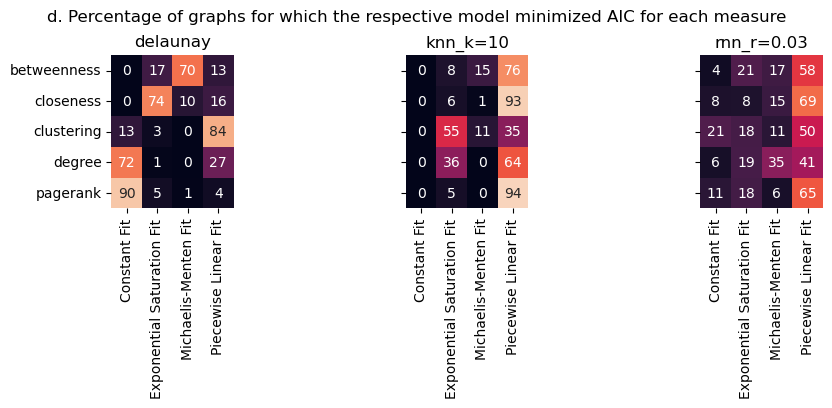

In [21]:
f, axs = plt.subplots(1, len(index), figsize=(10, 4), sharey=True)
for graph_type, df in plot_subset.sort_values(['graph_type'], ascending=False).groupby("graph_type"):
    i = index[graph_type]
    heatmap = pd.crosstab(df["measure"].values, df["best_fit_type"].values, normalize="index")*100
    sns.heatmap(heatmap, annot=True, square=True, fmt=".0f", ax=axs[i], cbar=False, vmin=0, vmax=100)
    axs[i].set_ylabel(None)
    axs[i].set_xlabel(None)
    axs[i].set_title(graph_type)
plt.suptitle("d. Percentage of graphs for which the respective model minimized AIC for each measure")
plt.tight_layout()
#plt.savefig("../result_plots/fits/AICS_type.svg", bbox_inches="tight")